# CT Gas Capex Analysis

Data source: Halcyon Gas Power Plant Tracker (17 July 2026), covering gas power plant projects across the US. We keep only CT projects with a reported cost ($/kW), then use regression analysis on that data to forecast CT capex from 2026 to 2032.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("Halcyon_July_CT.csv")
df.head()

,Plant / Unit Name,State,BA Code,Announcement Date,Planned / Operating Year,Technology Type,Capacity (MW),Cost ($/kW),CapEx ($M),Actual vs. Estimated Cost,Dollar Year,Latitude,Longitude,EIA Status,EIA Plant ID,
0,Thomas Fitzhugh,AR,SWPP,"Feb 26, 2024",-,Simple-Cycle Gas Turbine,140.5,978.95,93.00,Estimated,-,35.462382,-93.80493,201,Arkansas Electric Coop Corp,NaN
1,Ironwood Power Station,AR,MISO,"Nov 1, 2024",2028,Simple-Cycle Gas Turbine,446.0,"1,753.00",782.00,Estimated,-,34.433826,-92.9042,69750,Entergy Arkansas LLC,NaN
2,Apache Generating Station GT5 and GT6,AZ,WALC,"Oct 1, 2024",2025,Simple-Cycle Gas Turbine,84.0,920.37,77.00,Actual,2025.0,32.0603,-109.8931,160,Arizona Electric Pwr Coop Inc,NaN
3,Redhawk Plant Expansion,AZ,SRP,"Jul 8, 2024",2027,Simple-Cycle Gas Turbine,397.0,"1,115.87",443.00,Estimated,2024.0,33.334562,-112.8406,55455,Arizona Public Service Co,NaN
4,Black Mountain Expansion Project,AZ,TEPC,"Mar 8, 2024",2027,Simple-Cycle Gas Turbine,200.0,"1,090.00",218.00,Estimated,-,35.0361,-114.1594,56482,-,NaN


## Data Cleaning

Drop two types of outliers before fitting anything:
- Projects with a planned/operating year **after 2032**
- Projects with a cost **above $3000/kW**

In [2]:
df["Cost ($/kW)"] = df["Cost ($/kW)"].astype(str).str.replace(",", "").astype(float)
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Clean data: drop rows with year after 2032 or cost above 3000 $/kW (outliers)
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]
df.shape

(34, 16)

## Scatter plot: Cost vs. Year

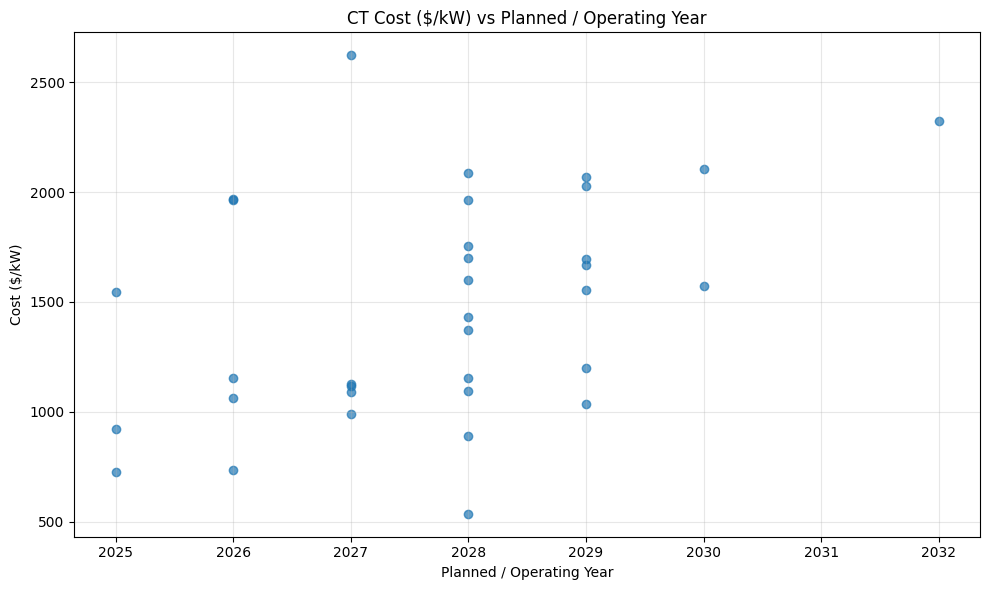

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"], alpha=0.7)
ax.set_xlabel("Planned / Operating Year")
ax.set_ylabel("Cost ($/kW)")
ax.set_title("CT Cost ($/kW) vs Planned / Operating Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Regression (all data)


CT — 34 plants
  Year  : 2025–2032  (mean 2027.7)
  Cost  : $536–$2622 /kW  (mean $1467, std $508)
  Regression: slope=134.1 $/kW/yr,  R²=0.170,  p=0.015


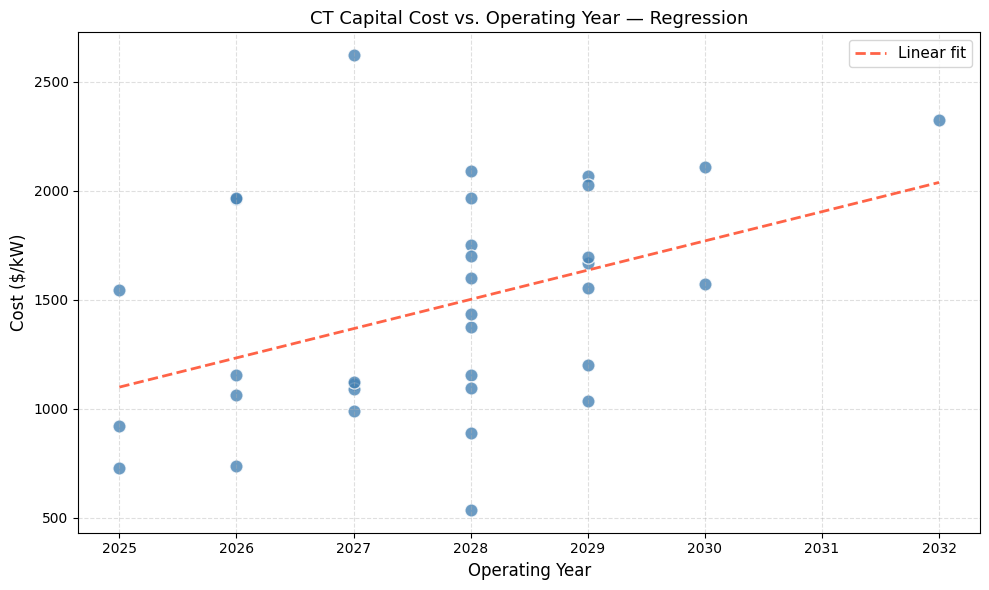

In [4]:
slope, intercept, r, p, stderr = linregress(df["Planned / Operating Year"], df["Cost ($/kW)"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"],
           color="steelblue", alpha=0.8, edgecolors="white", s=90)

x_range = np.linspace(df["Planned / Operating Year"].min(), df["Planned / Operating Year"].max(), 100)
ax.plot(x_range, intercept + slope * x_range,
        color="tomato", linewidth=2, linestyle="--", label="Linear fit")

print(f"\nCT — {len(df)} plants")
print(f"  Year  : {df['Planned / Operating Year'].min():.0f}–{df['Planned / Operating Year'].max():.0f}  (mean {df['Planned / Operating Year'].mean():.1f})")
print(f"  Cost  : ${df['Cost ($/kW)'].min():.0f}–${df['Cost ($/kW)'].max():.0f} /kW  (mean ${df['Cost ($/kW)'].mean():.0f}, std ${df['Cost ($/kW)'].std():.0f})")
print(f"  Regression: slope={slope:.1f} $/kW/yr,  R²={r**2:.3f},  p={p:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CT Capital Cost vs. Operating Year — Regression", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [5]:
# Extract regression statistics
regression_stats = pd.DataFrame([{
    "n_plants": len(df),
    "slope_$/kW_per_yr": slope,
    "intercept_$/kW": intercept,
    "r_squared": r**2,
    "p_value": p,
    "std_err": stderr,
}])
regression_stats

,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,34,134.088493,-270429.442652,0.170452,0.015238,52.292036



We fit `Cost ($/kW) = intercept + slope * Year` and get back:

- **p = 0.015 < 0.05** → this trend **is statistically significant**

In [6]:
# Regression forecast 2026-2032
years = np.arange(2026, 2033)
forecast = pd.DataFrame({
    "Year": years,
    "Cost_$/kW": np.round(intercept + slope * years, 1),
})
forecast.to_csv("ct_regression_forecast.csv", index=False)
forecast

,Year,Cost_$/kW
0,2026,1233.8
1,2027,1367.9
2,2028,1502.0
3,2029,1636.1
4,2030,1770.2
5,2031,1904.3
6,2032,2038.4


Unlike CCGT, we keep a **single forecast** for CT. This single regression forecast is exported to `ct_regression_forecast.csv`, which `gas_CAPEX_update.ipynb` then uses to update the Gas-CT `capcost` values in all 3 ATB scenario files (the CT input stays the same across `v1_low`, `v2_high`, `v3_all` — only the CCGT side varies).